Bias term ß₀ = -2.447852e+01
Computation time: 0.2291 seconds


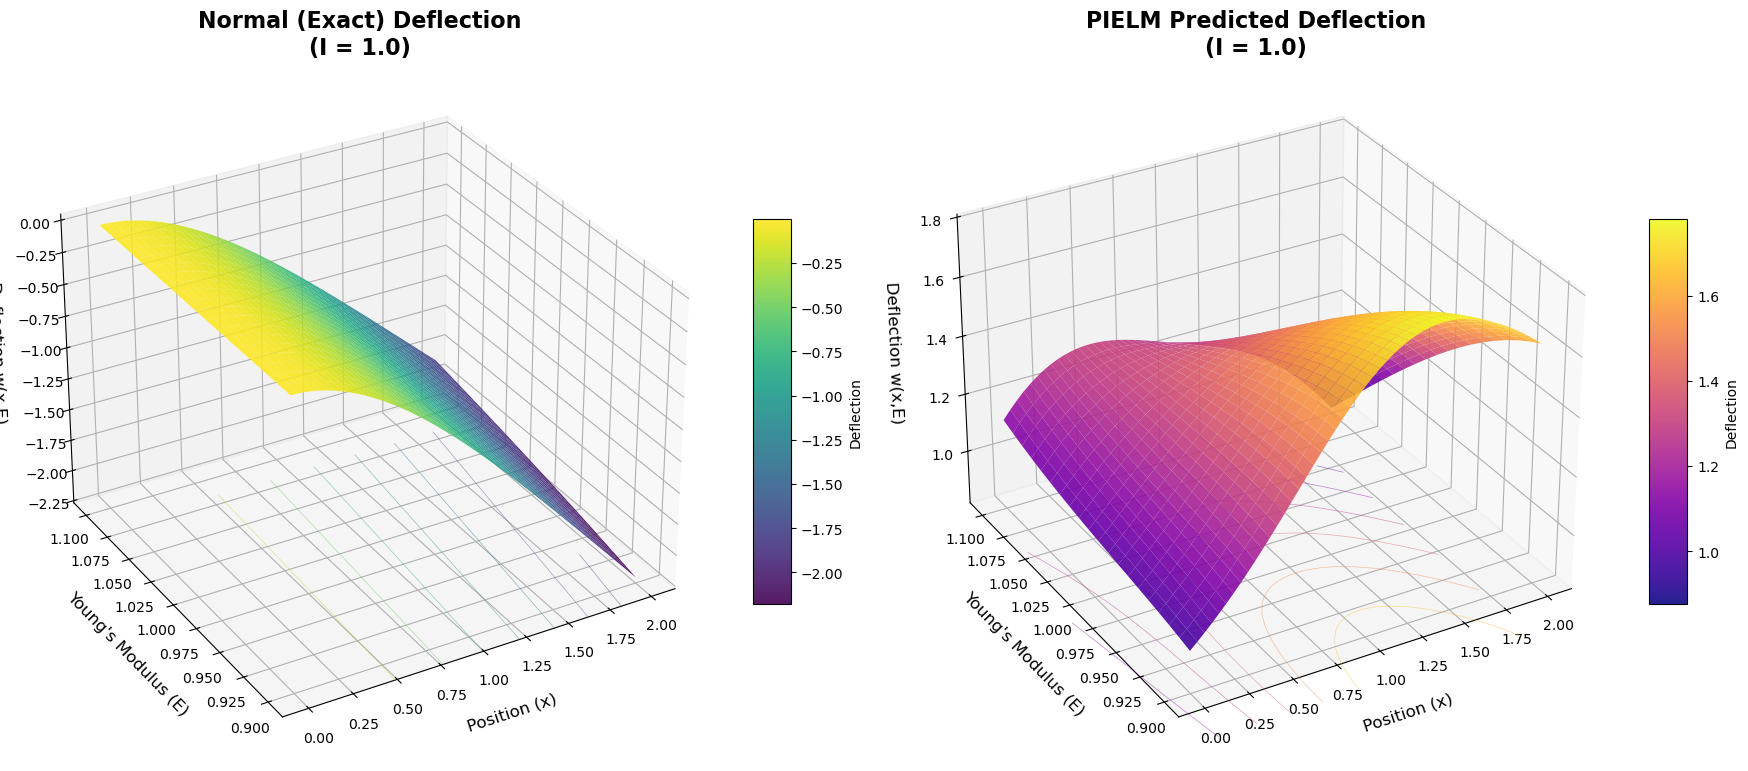

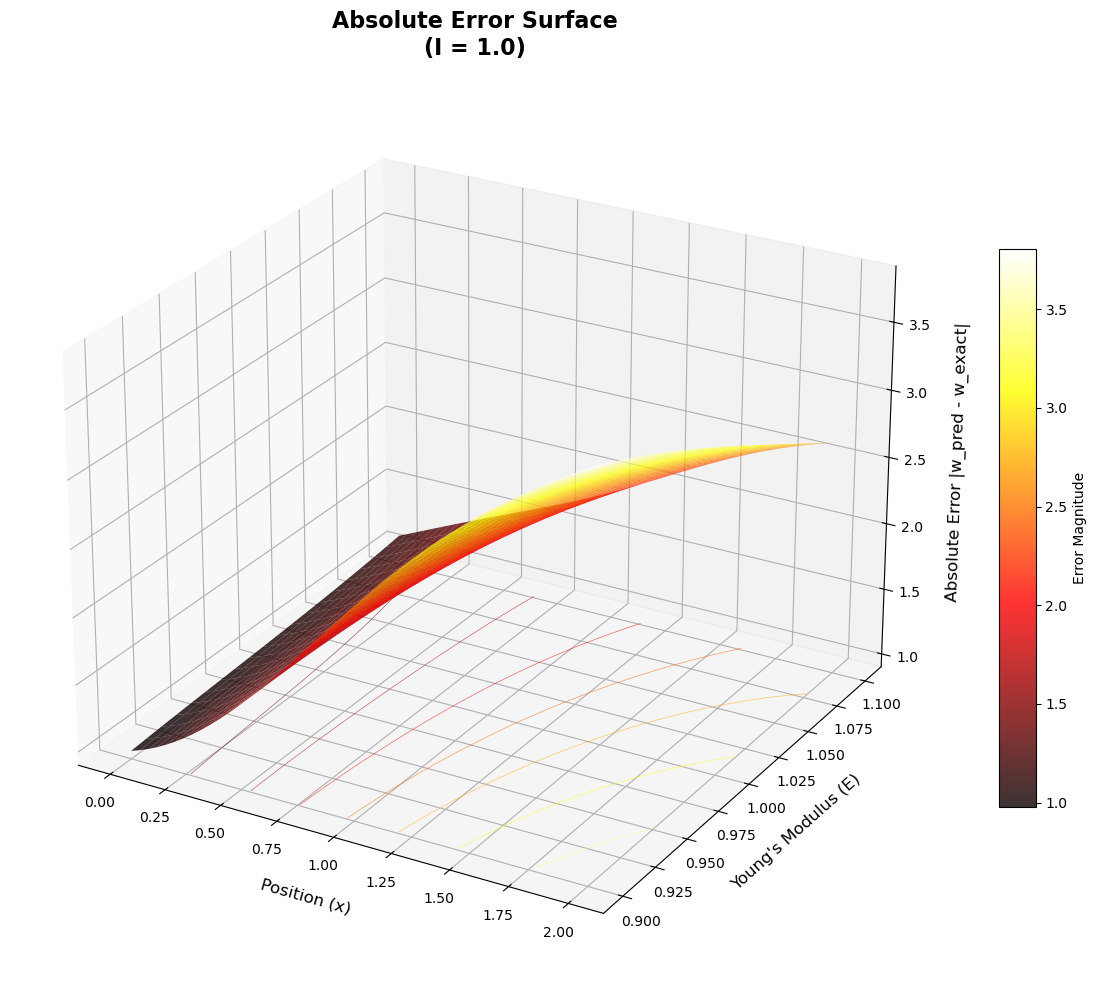


ERROR ANALYSIS
Mean Absolute Error: 2.174029
Maximum Error: 3.849700
Median Error: 2.153264
Error Standard Deviation: 0.748901
Relative L2 Error: 2.234769

Error at key locations:
----------------------------------------
At x=0 (should be 0): Mean error = 1.035582e+00
At x=L (should be 0): Mean error = 3.283845e+00
At x=L/2 (maximum deflection): Max error = 2.491701


In [3]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from timeit import default_timer

# ========== ADD LHS FUNCTION ==========
def lhs_sample(n, dim):
    """Latin Hypercube Sampling"""
    intervals = np.linspace(0, 1, n + 1)
    points = np.zeros((n, dim))
    for i in range(dim):
        perm = np.random.permutation(n)
        points[:, i] = np.random.uniform(intervals[:n], intervals[1:], size=n)[perm]
    return points
# =======================================

# Physical parameters
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# ELM setup
torch.manual_seed(42)
hidden_size = 50
W = torch.randn(3, hidden_size)
b = torch.randn(hidden_size)

def hidden_layer_3d_gaussian(xei):
    linear = xei @ W + b
    return torch.exp(-linear**2)

# Create grid for prediction (after training)
n_x = 50
n_E = 20

x_grid = torch.linspace(0, L, n_x)
E_grid = torch.linspace(E_range[0], E_range[1], n_E)

X, E = torch.meshgrid(x_grid, E_grid, indexing='ij')

# Fix I at middle value for comparison
I_fixed = 1.0  # Fixed I value for comparison

# ========== CHANGED: USE LHS INSTEAD OF RANDOM ==========
n_pde = 2000
# OLD: x_pde = torch.rand(n_pde, 1) * L
# OLD: E_pde = torch.rand(n_pde, 1) * (E_range[1] - E_range[0]) + E_range[0]
# OLD: I_pde = torch.rand(n_pde, 1) * (I_range[1] - I_range[0]) + I_range[0]

# NEW: Use LHS sampling
lhs_pde = lhs_sample(n_pde, 3)
x_pde = torch.tensor(lhs_pde[:, 0:1], dtype=torch.float32) * L
E_pde = torch.tensor(lhs_pde[:, 1:2], dtype=torch.float32) * (E_range[1] - E_range[0]) + E_range[0]
I_pde = torch.tensor(lhs_pde[:, 2:3], dtype=torch.float32) * (I_range[1] - I_range[0]) + I_range[0]

xe_pde = torch.cat([x_pde, E_pde, I_pde], dim=1).requires_grad_(True)

# Boundary points - ALSO CHANGED TO LHS
n_bc = 500
# OLD: E_bc = torch.rand(n_bc, 1) * (E_range[1] - E_range[0]) + E_range[0]
# OLD: I_bc = torch.rand(n_bc, 1) * (I_range[1] - I_range[0]) + I_range[0]

# NEW: Use LHS sampling for boundary points too
lhs_bc = lhs_sample(n_bc, 2)
E_bc = torch.tensor(lhs_bc[:, 0:1], dtype=torch.float32) * (E_range[1] - E_range[0]) + E_range[0]
I_bc = torch.tensor(lhs_bc[:, 1:2], dtype=torch.float32) * (I_range[1] - I_range[0]) + I_range[0]

x0_bc = torch.zeros(n_bc, 1)
xL_bc = torch.ones(n_bc, 1) * L

xe_0 = torch.cat([x0_bc, E_bc, I_bc], dim=1).requires_grad_(True)
xe_L = torch.cat([xL_bc, E_bc, I_bc], dim=1).requires_grad_(True)
# ========================================================

# Build PDE matrix A
start_time = default_timer()

H_pde = hidden_layer_3d_gaussian(xe_pde)
A_cols = []

for j in range(hidden_size):
    neuron_output = H_pde[:, j:j+1]

    grad1 = autograd.grad(neuron_output.sum(), xe_pde, create_graph=True)[0]
    first_deriv = grad1[:, 0:1]

    grad2 = autograd.grad(first_deriv.sum(), xe_pde, create_graph=True)[0]
    second_deriv = grad2[:, 0:1]

    grad3 = autograd.grad(second_deriv.sum(), xe_pde, create_graph=True)[0]
    third_deriv = grad3[:, 0:1]

    grad4 = autograd.grad(third_deriv.sum(), xe_pde, create_graph=True)[0]
    fourth_deriv = grad4[:, 0:1]

    A_cols.append(fourth_deriv)

E_vals = xe_pde[:, 1:2]
I_vals = xe_pde[:, 2:3]

w_xxxx = torch.hstack(A_cols)
A = E_vals * I_vals * w_xxxx

A_aug = torch.hstack([A, torch.zeros(n_pde, 1)])
b_pde = Q * torch.ones(n_pde, 1)

# Build boundary matrix C
def build_boundary_row(xe_points, derivative_order):
    H = hidden_layer_3d_gaussian(xe_points)
    num_points = xe_points.shape[0]
    row_parts = []

    for j in range(hidden_size):
        neuron_output = H[:, j:j+1]

        if derivative_order == 0:
            row_parts.append(neuron_output)
        else:
            current = neuron_output
            for _ in range(derivative_order):
                grad = autograd.grad(current.sum(), xe_points, create_graph=True)[0]
                current = grad[:, 0:1]
            row_parts.append(current)

    if derivative_order == 0:
        bias_col = torch.ones(num_points, 1)
    else:
        bias_col = torch.zeros(num_points, 1)

    return torch.hstack([torch.hstack(row_parts), bias_col])

boundary_rows = []
boundary_rows.append(build_boundary_row(xe_0, 0))
boundary_rows.append(build_boundary_row(xe_0, 1))
boundary_rows.append(build_boundary_row(xe_L, 2))
boundary_rows.append(build_boundary_row(xe_L, 3))

C_aug = torch.vstack(boundary_rows)
d = torch.zeros(4 * n_bc, 1)

# Solve for β
A_T_aug = A_aug.T
C_T_aug = C_aug.T

total_size = hidden_size + 1 + C_aug.shape[0]
KKT = torch.zeros(total_size, total_size)

KKT[:hidden_size+1, :hidden_size+1] = A_T_aug @ A_aug
KKT[:hidden_size+1, hidden_size+1:] = C_T_aug
KKT[hidden_size+1:, :hidden_size+1] = C_aug

rhs = torch.vstack([A_T_aug @ b_pde, d])

regularization = 1e-8 * torch.trace(A_T_aug @ A_aug) / (hidden_size + 1)
KKT[:hidden_size+1, :hidden_size+1] += regularization * torch.eye(hidden_size + 1)

solution = torch.linalg.solve(KKT, rhs)

beta_with_bias = solution[:hidden_size+1]
beta = beta_with_bias[:hidden_size]
beta_0 = beta_with_bias[hidden_size:].item()

print(f"Bias term ß₀ = {beta_0:.6e}")
print(f"Computation time: {default_timer() - start_time:.4f} seconds")

# ============================================
# CREATE 3D SURFACE PLOTS
# ============================================

# Prepare prediction points
X_flat = X.flatten().reshape(-1, 1)
E_flat = E.flatten().reshape(-1, 1)
I_flat = torch.ones_like(X_flat) * I_fixed

xe_pred = torch.cat([X_flat, E_flat, I_flat], dim=1)

# PIELM prediction
H_pred = hidden_layer_3d_gaussian(xe_pred)
w_pred_flat = H_pred @ beta + beta_0
w_pred_grid = w_pred_flat.reshape(n_x, n_E)

# Exact solution
w_exact_grid = analytical_solution(X, E, torch.ones_like(X) * I_fixed)

# Convert to numpy for plotting
X_np = X.detach().numpy()
E_np = E.detach().numpy()
w_pred_np = w_pred_grid.detach().numpy()
w_exact_np = w_exact_grid.detach().numpy()

# Create figure with 2 subplots
fig = plt.figure(figsize=(18, 8))

# Plot 1: Normal (Exact) Deflection
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_np, E_np, w_exact_np, cmap='viridis', 
                        alpha=0.9, linewidth=0.1, antialiased=True)

# Add contour lines on the base
cset1 = ax1.contour(X_np, E_np, w_exact_np, zdir='z', offset=w_exact_np.min() - 0.2, 
                   cmap='viridis', alpha=0.5, linewidths=0.5)

ax1.set_title(f'Normal (Exact) Deflection\n(I = {I_fixed})', fontsize=16, fontweight='bold')
ax1.set_xlabel('Position (x)', fontsize=12, labelpad=10)
ax1.set_ylabel('Young\'s Modulus (E)', fontsize=12, labelpad=10)
ax1.set_zlabel('Deflection w(x,E)', fontsize=12, labelpad=10)
ax1.view_init(elev=30, azim=-120)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Deflection')

# Plot 2: PIELM Predicted Deflection
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_np, E_np, w_pred_np, cmap='plasma', 
                        alpha=0.9, linewidth=0.1, antialiased=True)

# Add contour lines on the base
cset2 = ax2.contour(X_np, E_np, w_pred_np, zdir='z', offset=w_pred_np.min() - 0.2, 
                   cmap='plasma', alpha=0.5, linewidths=0.5)

ax2.set_title(f'PIELM Predicted Deflection\n(I = {I_fixed})', fontsize=16, fontweight='bold')
ax2.set_xlabel('Position (x)', fontsize=12, labelpad=10)
ax2.set_ylabel('Young\'s Modulus (E)', fontsize=12, labelpad=10)
ax2.set_zlabel('Deflection w(x,E)', fontsize=12, labelpad=10)
ax2.view_init(elev=30, azim=-120)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='Deflection')

plt.tight_layout()
plt.show()

# ============================================
# ADDITIONAL: ERROR SURFACE PLOT
# ============================================

fig2 = plt.figure(figsize=(12, 10))
ax3 = fig2.add_subplot(111, projection='3d')

# Calculate error
error_grid = np.abs(w_pred_np - w_exact_np)

# Plot error surface
surf3 = ax3.plot_surface(X_np, E_np, error_grid, cmap='hot', 
                        alpha=0.8, linewidth=0.1, antialiased=True)

# Add contour lines
cset3 = ax3.contour(X_np, E_np, error_grid, zdir='z', offset=error_grid.min() - 0.05, 
                   cmap='hot', alpha=0.6, linewidths=0.5)

ax3.set_title(f'Absolute Error Surface\n(I = {I_fixed})', fontsize=16, fontweight='bold')
ax3.set_xlabel('Position (x)', fontsize=12, labelpad=10)
ax3.set_ylabel('Young\'s Modulus (E)', fontsize=12, labelpad=10)
ax3.set_zlabel('Absolute Error |w_pred - w_exact|', fontsize=12, labelpad=10)
ax3.view_init(elev=25, azim=-60)
fig2.colorbar(surf3, ax=ax3, shrink=0.6, aspect=15, label='Error Magnitude')

plt.tight_layout()
plt.show()

# ============================================
# CALCULATE AND PRINT ERROR STATISTICS
# ============================================

error_flat = error_grid.flatten()
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)
print(f"Mean Absolute Error: {np.mean(error_flat):.6f}")
print(f"Maximum Error: {np.max(error_flat):.6f}")
print(f"Median Error: {np.median(error_flat):.6f}")
print(f"Error Standard Deviation: {np.std(error_flat):.6f}")
print(f"Relative L2 Error: {np.linalg.norm(error_flat) / np.linalg.norm(w_exact_np.flatten()):.6f}")

# Calculate error at specific points
print("\nError at key locations:")
print("-"*40)
print(f"At x=0 (should be 0): Mean error = {error_grid[0, :].mean():.6e}")
print(f"At x=L (should be 0): Mean error = {error_grid[-1, :].mean():.6e}")
print(f"At x=L/2 (maximum deflection): Max error = {error_grid[n_x//2, :].max():.6f}")
print("="*60)